In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from diffpy.mpdf import *
from maginteractions import MagInteractions

%matplotlib notebook

In [2]:
mcif = 'MnTeData/0.800_MnTe.mcif'
magstruc = create_from_mcif(mcif, ffparamkey='Mn2')

magstruc.makeAll()

MagStructure creation from mcif file successful.


In [3]:
tn_idx = 11
high_temp_idx = 4

[data_temps, xi_in, xi_in_err] = np.loadtxt('MnTeData/xiIn_vs_T.txt', skiprows=1, delimiter=' ').T
[_, xi_out, xi_out_err] = np.loadtxt('MnTeData/xiOut_vs_T.txt', skiprows=1, delimiter=' ').T

[_, lmop, lmop_err] = np.loadtxt('MnTeData/m-v-T_1p5-20.txt', skiprows=1, delimiter=' ')[tn_idx:].T

[data_temps_high, xi_in_high, xi_in_high_err] = np.loadtxt('MnTeData/xiIn_vs_T.txt', skiprows=1,
                                                           delimiter=' ')[high_temp_idx:].T
[_, xi_out_high, xi_out_high_err] = np.loadtxt('MnTeData/xiOut_vs_T.txt', skiprows=1,
                                                delimiter=' ')[high_temp_idx:].T

[_, lmop_high, lmop_high_err] = np.loadtxt('MnTeData/m-v-T_1p5-20.txt', skiprows=1,
                                            delimiter=' ')[high_temp_idx + tn_idx:].T

# Previously published values

In [4]:
temps = np.linspace(300.0, 500.0, 101)

/home/edison/Documents/Projects/MagInteractions/maginteractions.py:225: ComplexWarning: Casting complex values to real discards the imaginary part
  u_q[k] = eig_vecs.astype('float64')


<IPython.core.display.Javascript object>


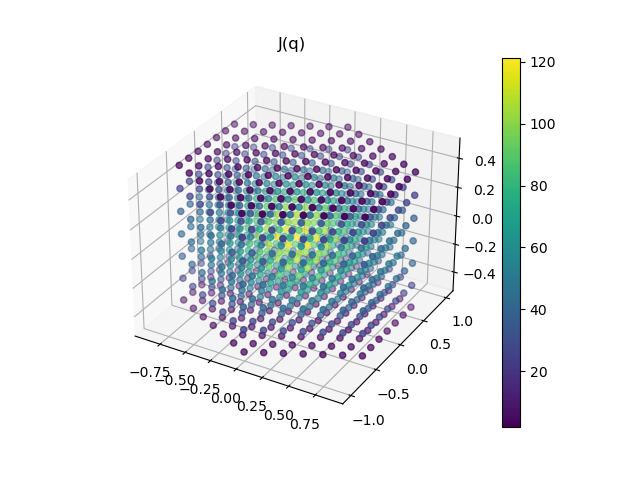

In [5]:
r_max = 8.0
spin_squared = 25/4
spin_dim = 3

### Use parameters from Mu et al. (2019)

j_ij_19 = [-35.6491, -0.315643, -4.64181, -1.85672]
magint_19 = MagInteractions(magstruc=magstruc, temperatures=temps, j_ij=j_ij_19,
                            spin_squared=spin_squared, r_max=r_max, spin_dim=spin_dim)
magint_19.make_interaction_matrix()
magint_19.calculate_orf_reciprocal_space(n_bz_vecs=6)

qxs, qys, qzs = magint_19.q_vecs.T

fig, ax = plt.subplots(subplot_kw = {"projection": "3d"})
jqPlot = ax.scatter(qxs, qys, qzs, c = magint_19.j_q[:, -1])
fig.colorbar(jqPlot)
ax.set_title('J(q)')
plt.show()

<IPython.core.display.Javascript object>


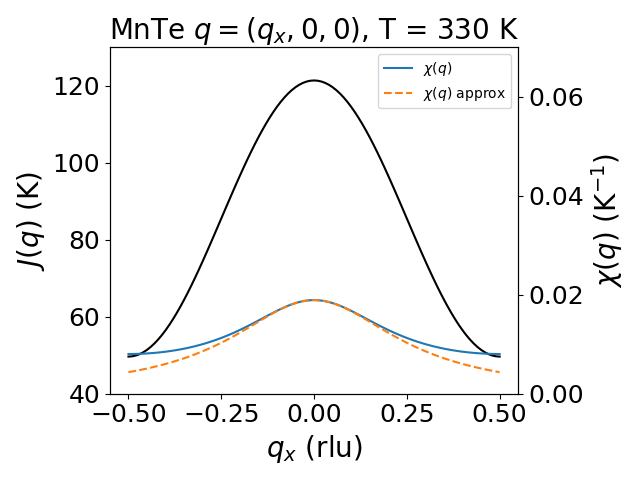

In [6]:
qa = magint_19.recip_lats[0,0]

qx = np.linspace(-qa/2,qa/2,101)
qy = 0
qz = 0

mode = -1

Jqs = np.zeros_like(qx)
for i in range(qx.shape[0]):
    Jqs[i] = magint_19.calc_j_q([qx[i],qy,qz])[mode]
    
j0 = Jqs[50] 
jpp = (Jqs[49] + Jqs[51] - 2*j0)/qx[51]**2
    
tidx = 3
chi0 = spin_squared / 3 / data_temps[tidx]
chi = chi0/(1-chi0*(Jqs-magint_19.orfs[tidx]))

xi_plot = np.sqrt(-0.5*jpp/(1/chi0 - j0 + magint_19.orfs[tidx]))
chi_approx = -2/jpp/(xi_plot**(-2) + qx**2)

fontsize = 20
ticksize = 18

fig, ax1 = plt.subplots()
# ax.plot_surface(qx, qy, chi)
ax1.plot(qx / qa, Jqs, c='black')
ax1.set_title(fr'MnTe $q = (q_x,0,0)$, T = {int(data_temps[tidx])} K', fontsize=fontsize)
ax1.set_xlabel(r'$q_x$ (rlu)', fontsize=fontsize)
ax1.set_ylabel(r'$J(q)$ (K)', fontsize=fontsize)
ax1.set_ylim(40,130)
ax1.tick_params(axis = 'x', labelsize=ticksize)
ax1.tick_params(axis = 'y', labelsize=ticksize)

ax2 = ax1.twinx()
ax2.plot(qx / qa, chi, '-', label=r'$\chi(q)$')
ax2.plot(qx / qa, chi_approx, '--', label=r'$\chi(q)$ approx')
ax2.set_ylabel(r'$\chi(q)$ (K$^{-1}$)', fontsize=fontsize)
ax2.set_ylim(0, 0.07)
ax2.tick_params(axis='x', labelsize=ticksize)
ax2.tick_params(axis='y', labelsize=ticksize)
ax2.legend()

fig.tight_layout()

plt.savefig('figures/MnTeJq.png',dpi=600)
plt.show()

In [7]:
ord_vec = np.zeros(3)
calc_orf = True
sum_rule_orf = False

### Use parameters from Mu et al. (2019)
magint_19.filter_spin_positions()
magint_19.calculate_correlation_parameters(ord_vec=ord_vec, calc_orf=calc_orf, sum_rule_orf=sum_rule_orf)

lmop_19 = magint_19.lmops
xis_19 = np.nan_to_num(np.linalg.eigvals(magint_19.damping_matrices)**(-1/2), nan=50)

### Use parameters from Szuszkiewicz et al. (2006)

j_ij_06 = [-43.0, 1.34, -5.74]
magint_06 = MagInteractions(magstruc=magstruc, temperatures=temps, j_ij=j_ij_06,
                            spin_squared=spin_squared, r_max=r_max, spin_dim=spin_dim)
magint_06.make_interaction_matrix()
magint_06.filter_spin_positions()
magint_06.calculate_correlation_parameters(ord_vec=ord_vec, calc_orf=calc_orf, sum_rule_orf=sum_rule_orf)

lmop_06 = magint_06.lmops
xis_06 = np.nan_to_num(np.linalg.eigvals(magint_06.damping_matrices)**(-1/2), nan=50)

/home/edison/anaconda3/envs/diffpy/lib/python3.7/site-packages/diffpy/mpdf/magstructure.py:987: RuntimeWarning: invalid value encountered in true_divide
  distanceVecsN = distanceVecs/np.apply_along_axis(np.linalg.norm,1,distanceVecs)[:,np.newaxis]


<IPython.core.display.Javascript object>


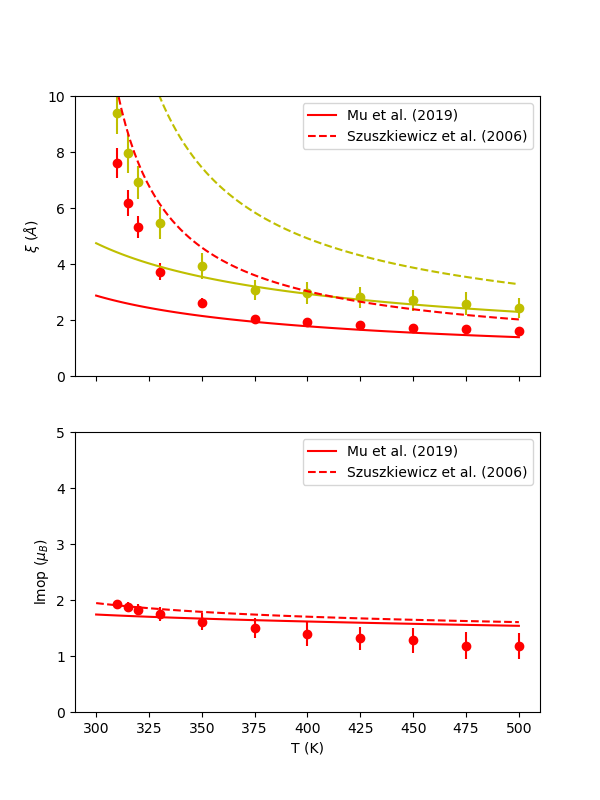

In [8]:
fig, (ax1, ax2) = plt.subplots(2,1,sharex=True, figsize=(6,8))

ax1.scatter(data_temps, xi_in, c='r')
ax1.scatter(data_temps, xi_out, c='y')
ax1.errorbar(data_temps, xi_in, yerr = xi_in_err, fmt='none', c='r')
ax1.errorbar(data_temps, xi_out, yerr = xi_out_err, fmt='none', c='y')
ax1.plot(temps, xis_19[:,0], '-', c='r', label='Mu et al. (2019)')
ax1.plot(temps, xis_19[:,1], '-', c='y')
ax1.plot(temps, xis_06[:,0], '--', c='r', label='Szuszkiewicz et al. (2006)')
ax1.plot(temps, xis_06[:,1], '--', c='y')
ax1.set_ylim(0, 10)
ax1.set_ylabel(r'$\xi$ ($\AA$)')
ax1.legend()

ax2.scatter(data_temps, lmop, c='r')
ax2.errorbar(data_temps, lmop, yerr = lmop_err, fmt='none', c='r')
ax2.plot(temps, lmop_19, '-', c='r', label='Mu et al. (2019)')
ax2.plot(temps, lmop_06, '--', c='r', label='Szuszkiewicz et al. (2006)')
ax2.set_ylim(0, 5)
ax2.set_xlabel('T (K)')
ax2.set_ylabel(r'lmop ($\mu_B$)')
ax2.legend()

plt.show()

<IPython.core.display.Javascript object>


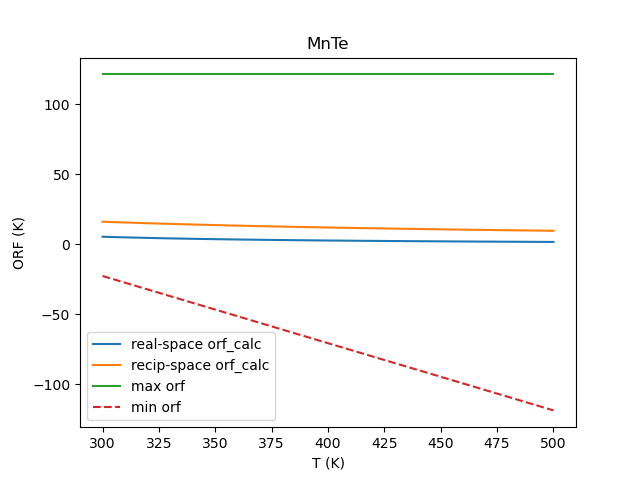

In [9]:
orfs_reciprocal_space = magint_19.calculate_orf_reciprocal_space(n_bz_vecs=6, store=False)

fig, ax = plt.subplots()
ax.plot(temps, magint_19.orfs, label='real-space orf_calc')
ax.plot(temps,orfs_reciprocal_space, label='recip-space orf_calc')
ax.plot(temps,np.max(magint_19.j_q) * np.ones_like(temps), label='max orf')
ax.plot(temps,np.max(magint_19.j_q)- 3 * temps / spin_squared, '--', label='min orf')
ax.legend()
ax.set_xlabel('T (K)')
ax.set_ylabel('ORF (K)')
ax.set_title('MnTe')
plt.show()

<IPython.core.display.Javascript object>


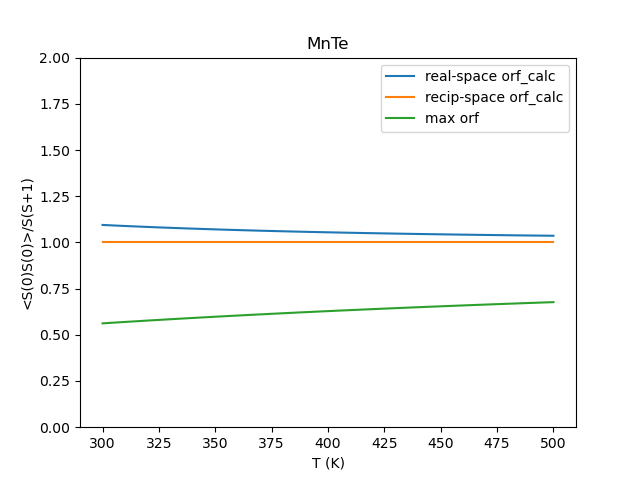

In [10]:
chi_0 = magint_19.calc_chi_0()
orf_sum_real = np.array([np.sum((1 - chi_0[i] * (magint_19.j_q - magint_19.orfs[i]))**(-1))
                         for i in range(len(temps))])
orf_sum_recip = np.array([np.sum((1 - chi_0[i] * (magint_19.j_q - orfs_reciprocal_space[i]))**(-1))
                          for i in range(len(temps))])
orf_sum_max = np.array([np.sum((1 - chi_0[i] * (magint_19.j_q - np.max(magint_19.j_q)))**(-1))
                        for i in range(len(temps))])

fig, ax = plt.subplots()
ax.plot(temps, orf_sum_real / (magint_19.N * len(magint_19.q_vecs)), label='real-space orf_calc')
ax.plot(temps, orf_sum_recip / (magint_19.N * len(magint_19.q_vecs)), label='recip-space orf_calc')
ax.plot(temps, orf_sum_max / (magint_19.N * len(magint_19.q_vecs)), label='max orf')
ax.set_xlabel('T (K)')
ax.set_ylabel('<S(0)S(0)>/S(S+1)')
ax.set_title('MnTe')
ax.legend()
ax.set_ylim(0, 2)
plt.show()

# Fit

In [11]:
spin_squared = 25/4

def residuals(theta):
    
    j_ij = theta
    
    magint = MagInteractions(magstruc=magstruc, temperatures=data_temps, j_ij=j_ij,
                             spin_squared=spin_squared, r_max=r_max, spin_dim=spin_dim)
    magint.make_interaction_matrix()
    magint.filter_spin_positions()
    magint.calculate_correlation_parameters(ord_vec=ord_vec, calc_orf=calc_orf,
                                               sum_rule_orf=sum_rule_orf)

    lmops = magint.lmops
    
    d_eigvals, d_eigvecs = np.linalg.eig(magint.damping_matrices)
    xis = np.nan_to_num(d_eigvals**(-0.5), nan=100)
    xis = np.where(xis > 100, 100, xis)
    
    xis_in = np.zeros_like(data_temps)
    xis_out = np.zeros_like(data_temps)
    
    out_vec = np.array([0, 0, 1])
    for i in range(len(data_temps)):
        arg_list = [0, 1, 2]
        out_arg = np.argmax(np.abs(d_eigvecs[i].T @ out_vec))
        arg_list.remove(out_arg)
        xis_in[i] = np.prod(xis[i, arg_list])**(0.5)
        xis_out[i] = xis[i,out_arg]
        
    res = np.concatenate([xis_in, xis_out, lmops]) - np.concatenate([xi_in, xi_out, lmop])
    weights = 1 / np.concatenate([xi_in_err, xi_out_err, lmop_err])

    return weights * res

theta = [-27, 2, -2]
# theta = j_ij_06
# theta = j_ij_19
result = least_squares(residuals, theta, method = 'lm')

In [12]:
j_ij_fit = result.x

magint_fit = MagInteractions(magstruc=magstruc, temperatures=temps, j_ij=j_ij_fit,
                         spin_squared=spin_squared, r_max=r_max, spin_dim=spin_dim)
magint_fit.make_interaction_matrix()
magint_fit.calculate_correlation_parameters(ord_vec=ord_vec, calc_orf=calc_orf,
                                            sum_rule_orf=sum_rule_orf)

lmops_fit = magint_fit.lmops

d_fit_eigvals, d_fit_eigvecs = np.linalg.eig(magint_fit.damping_matrices)
xis_fit = np.nan_to_num(d_fit_eigvals**(-0.5), nan=100)
xis_fit = np.where(xis_fit > 100, 100, xis_fit)

xis_in_fit = np.zeros_like(temps)
xis_out_fit = np.zeros_like(temps)

out_vec = np.array([0, 0, 1])
for i in range(len(temps)):
    arg_list = [0, 1, 2]
    out_arg = np.argmax(np.abs(d_fit_eigvecs[i].T @ out_vec))
    arg_list.remove(out_arg)
    xis_in_fit[i] = np.prod(xis_fit[i, arg_list])**(0.5)
    xis_out_fit[i] = xis_fit[i,out_arg]

In [13]:
print(result.jac.T @ result.jac)
print(np.diag(result.jac.T @ result.jac)**(-1/2))
print(np.diag(np.linalg.inv(result.jac.T @ result.jac))**(1/2))

[[  2.5336711   -8.79248437  18.90879531]
 [ -8.79248437  39.75878955 -81.86810444]
 [ 18.90879531 -81.86810444 170.17693511]]
[0.62823898 0.15859278 0.07665662]
[2.32242395 2.49801523 1.40907777]


In [14]:
jac_vals, jac_vecs = np.linalg.eig(result.jac.T @ result.jac)
for i in range(len(jac_vals)):
    print(jac_vals[i]**(-0.5))
    print(jac_vecs[:, i])

0.0687272070480905
[-0.0991901   0.43188511 -0.89645779]
1.2159066084403016
[0.78831348 0.58386713 0.1940645 ]
3.483687836800803
[-0.60722581  0.68744049  0.39837469]


In [15]:
name = ["Szuszkiewicz", "Mu", "Fit"]
j_ijs = [j_ij_06, j_ij_19, result.x]
costs = [0.5 * np.sum(residuals(j_ij_06)**2),
         0.5 * np.sum(residuals(j_ij_19)**2),
         result.cost]

for i in range(3):
    print(f'\n{name[i]}')

    for k, j in enumerate(j_ijs[i]):
        print(f'J{k+1}={j}')

    print(f'Cost = {costs[i]}')


Szuszkiewicz
J1=-43.0
J2=1.34
J3=-5.74
Cost = 543.9184332778385

Mu
J1=-35.6491
J2=-0.315643
J3=-4.64181
J4=-1.85672
Cost = 180.1727082711962

Fit
J1=-35.360208201506794
J2=-1.858411989023535
J3=-6.833428489436304
Cost = 94.46589463834033


J1=-41.98598078022873
J2=10.690205399428777
J3=-0.5688842271278799
Cost = 119.83503485210255

J1=-35.360208201506794
J2=-1.858411989023535
J3=-6.833428489436304
Cost = 94.46589463834033


In [18]:
rdat, gobs, nucpdf, mpdfcalc = np.loadtxt('MnTeData/fit_MnTe_stream_330K_1.5-20.txt',
                                          skiprows=1, delimiter=' ').T
mpdfobs = gobs - nucpdf

mpdf_t_idx = 15
print(f'T = {temps[mpdf_t_idx]}')

paraScale = 200.0

magstruc_temp = magstruc

magstruc_temp.dampingMat = magint_fit.damping_matrices[mpdf_t_idx]
magstruc_temp.makeAll()

mc = MPDFcalculator(magstruc_temp, rmin=1.5, qmax=25.0, qdamp=0.03)
mc.paraScale = paraScale
mc.ordScale = magutils.calculate_ordered_scale(magstruc_temp, magint_fit.lmops[mpdf_t_idx])
rcalc, dcalc = mc.calc(correlationMethod='full', normalized=False, both=False)

T = 330.0


<IPython.core.display.Javascript object>


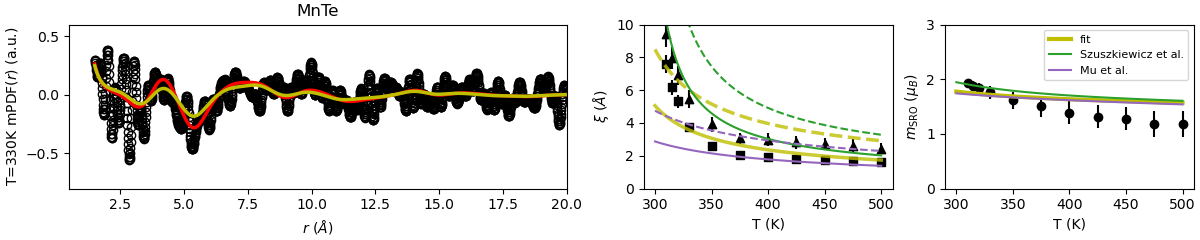

In [20]:
from matplotlib.gridspec import GridSpec

labelsize=10
ticksize=10

fig = plt.figure(layout="constrained", figsize=(12, 2.4))
gs = GridSpec(1, 4, figure=fig)
ax_mpdf = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[0, 2])
ax2 = fig.add_subplot(gs[0, 3])

ax_mpdf.plot(rdat, mpdfobs, 'bo', label="mPDF(r) data",
            markerfacecolor='none', markeredgecolor='black')
ax_mpdf.plot(rdat, mpdfcalc, 'r-', lw=2.5, label="mPDF(r) atomistic fit")
ax_mpdf.plot(rcalc, 0.05 * dcalc, 'y-', lw=2.5, label="mPDF(r) from exchange fits")
ax_mpdf.set_title('MnTe')
ax_mpdf.set_xlim(0.5, 20)
ax_mpdf.set_ylim(-0.8, 0.6)
ax_mpdf.set_xlabel(r'$r$ ($\AA$)', fontsize=labelsize)
ax_mpdf.set_ylabel(r'T=330K mPDF$(r)$ (a.u.)',fontsize=labelsize)

ax1.scatter(data_temps, xi_in, c='black', marker='s', label=r'data')
ax1.scatter(data_temps, xi_out, c='black', marker='^')
ax1.errorbar(data_temps, xi_in, yerr=xi_in_err, fmt='none', c='black')
ax1.errorbar(data_temps, xi_out, yerr=xi_out_err, fmt='none', c='black')
ax1.plot(temps, xis_in_fit, '-', c='y', lw=2.5, label='fit', alpha=0.8)
ax1.plot(temps, xis_out_fit, '--', c='y', lw=2.5, alpha=0.8)
ax1.plot(temps, xis_06[:,0], '-', c='tab:green')
ax1.plot(temps, xis_06[:,1], '--', c='tab:green')
ax1.plot(temps, xis_19[:,0], '-', c='tab:purple')
ax1.plot(temps, xis_19[:,1], '--', c='tab:purple')
ax1.set_xlim(290, 510)
ax1.set_ylim(0, 10)
ax1.set_xlabel('T (K)', fontsize=labelsize)
ax1.set_ylabel(r'$\xi$ ($\AA$)', fontsize=labelsize)
ax1.tick_params(axis = 'x', labelsize=ticksize)
ax1.tick_params(axis = 'y', labelsize=ticksize)

tidx_06 = 0
tidx_19 = 0
ax2.scatter(data_temps, lmop, c = 'black')
ax2.errorbar(data_temps, lmop, yerr = lmop_err, fmt = 'none', c = 'black')
ax2.plot(temps, lmops_fit, c = 'y', lw = 3, label = 'fit', alpha = 1)
ax2.plot(temps[tidx_06:], lmop_06[tidx_06:], '-', c = 'tab:green', label = 'Szuszkiewicz et al.')
ax2.plot(temps[tidx_19:], lmop_19[tidx_19:], '-', c = 'tab:purple', label = 'Mu et al.')
ax2.set_xlim(290, 510)
ax2.set_ylim(0, 3)
ax2.set_xlabel('T (K)', fontsize=labelsize)
ax2.set_ylabel(r'$m_{\mathrm{SRO}}$ ($\mu_B$)', fontsize = labelsize)
ax2.legend(fontsize=8)
ax2.tick_params(axis='x', labelsize=ticksize)
ax2.tick_params(axis='y', labelsize=ticksize)


plt.savefig('figures/MnTeFits.png', dpi = 1200)
plt.show()